<a href="https://colab.research.google.com/github/PawaniMekhala/AI-Driven-Student-Dropout-Prediction/blob/main/04_advanced_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup & Load Data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

X_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_train.csv")
y_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_train.csv").values.ravel()

X_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_test.csv")
y_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_test.csv").values.ravel()

# Install XGBoost
!pip install xgboost


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
     min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
# Evaluate Random Forest
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89       601
           1       0.76      0.76      0.76       284

    accuracy                           0.85       885
   macro avg       0.82      0.82      0.82       885
weighted avg       0.85      0.85      0.85       885



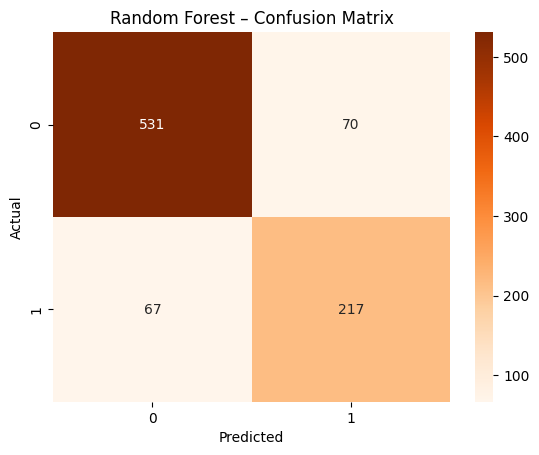

In [ ]:
# Random Forest – Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Feature Importance
importances_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances_rf.head(10)

,Feature,Importance
2,Curricular units 1st sem (grade),0.166060
228,Tuition fees up to date_1,0.091317
358,Curricular units 1st sem (approved)_6,0.060064
230,Scholarship holder_1,0.044797
227,Debtor_1,0.032737
1,Admission grade,0.026514
0,Previous qualification (grade),0.025131
21,Application mode_39,0.024002
229,Gender_1,0.022875
359,Curricular units 1st sem (approved)_7,0.020627


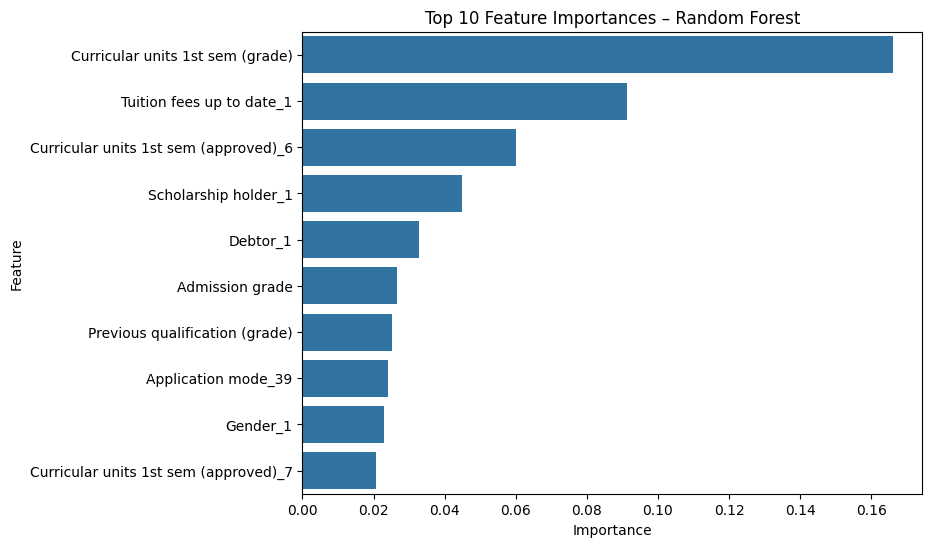

In [ ]:
# Feature Importance
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importances_rf.head(10)
)
plt.title("Top 10 Feature Importances – Random Forest")
plt.show()


In [ ]:
# Save Random Forest results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_rf)],
    "F1-score": [f1_score(y_test, y_pred_rf)]
})

rf_results.to_csv(
    f"{PROJECT_ROOT}/results/metrics/random_forest_results.csv",
    index=False
)


In [ ]:
# import and Train XGBoost (Reduce XGBoost overfitting)
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# import and Train XGBoost (before reduce overfitting)
# xgb = XGBClassifier(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
#     random_state=42,
#     eval_metric='logloss'
# )

# xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Evaluate XGBoost
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88       601
           1       0.72      0.80      0.76       284

    accuracy                           0.84       885
   macro avg       0.81      0.83      0.82       885
weighted avg       0.84      0.84      0.84       885



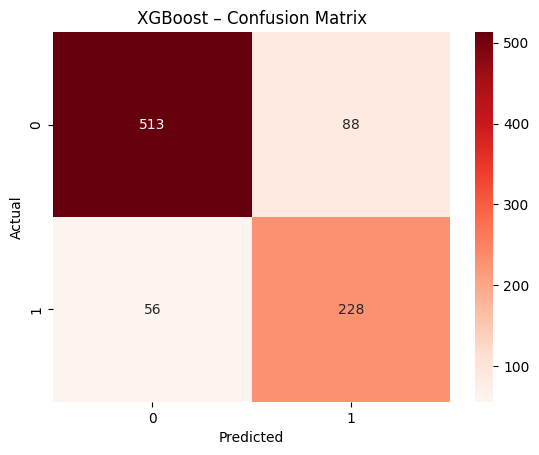

In [ ]:
# confusion matrix XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost – Confusion Matrix")
plt.show()


In [ ]:
# Feature Importance
importances_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances_xgb.head(10)


,Feature,Importance
228,Tuition fees up to date_1,0.080495
2,Curricular units 1st sem (grade),0.060236
358,Curricular units 1st sem (approved)_6,0.038953
230,Scholarship holder_1,0.038087
359,Curricular units 1st sem (approved)_7,0.031791
355,Curricular units 1st sem (approved)_3,0.028941
357,Curricular units 1st sem (approved)_5,0.027329
35,Course_171,0.026594
354,Curricular units 1st sem (approved)_2,0.023670
227,Debtor_1,0.021564


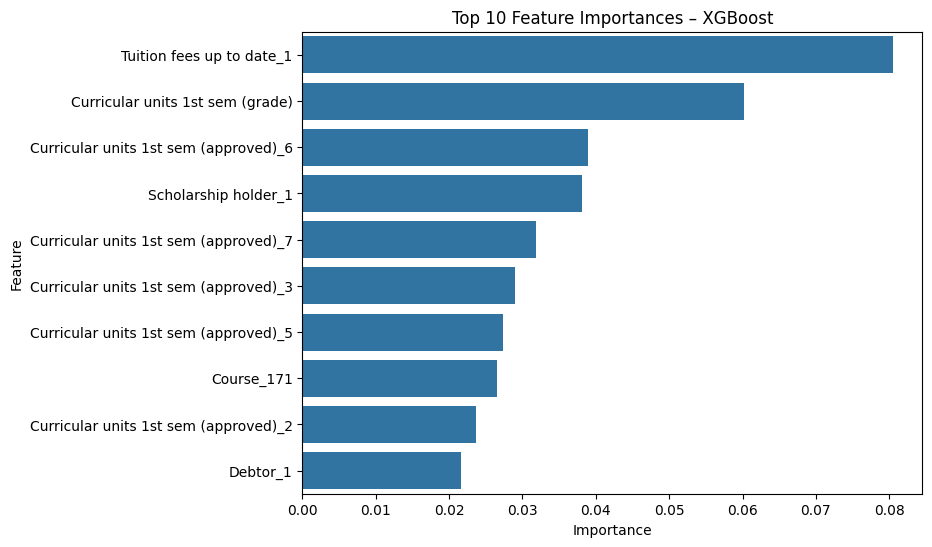

In [ ]:
# Feature Importance
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importances_xgb.head(10)
)
plt.title("Top 10 Feature Importances – XGBoost")
plt.show()

In [ ]:
# Save XGBoost results
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_xgb)],
    "Precision": [precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_xgb)],
    "F1-score": [f1_score(y_test, y_pred_xgb)]
})

xgb_results.to_csv(
    f"{PROJECT_ROOT}/results/metrics/xgboost_results.csv",
    index=False
)

In [ ]:
# Overfitting Check
print("Random Forest Train Recall:", recall_score(y_train, rf.predict(X_train)))
print("Random Forest Test Recall :", recall_score(y_test, y_pred_rf))

print("XGBoost Train Recall:", recall_score(y_train, xgb.predict(X_train)))
print("XGBoost Test Recall :", recall_score(y_test, y_pred_xgb))


Random Forest Train Recall: 0.8786279683377308
Random Forest Test Recall : 0.7640845070422535
XGBoost Train Recall: 0.7994722955145118
XGBoost Test Recall : 0.8028169014084507
